In [ ]:
!pip install torch_geometric ogb -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.convs.append(GCNConv(hidden_channels, out_channels))

        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        return x

In [3]:
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected, AddSelfLoops, Compose
import time

if not hasattr(torch.load, '_patched'):
    _original_load = torch.load

    def _patched_load(f, **kwargs):
        kwargs["weights_only"] = False
        return _original_load(f, **kwargs)

    _patched_load._patched = True
    torch.load = _patched_load

dataset = PygNodePropPredDataset(
    name='ogbn-arxiv',
    transform=Compose([ToUndirected(), AddSelfLoops()])
)

split_idx = dataset.get_idx_split()
data = dataset[0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

train_idx = split_idx['train'].to(device)
val_idx   = split_idx['valid'].to(device)
test_idx  = split_idx['test'].to(device)

print(data)
print(f"Device: {device}")
print(f"Num classes: {dataset.num_classes}")

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:02<00:00, 31.90it/s]
Processing...


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 9868.95it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 355.69it/s]

Saving...



Done!


Data(num_nodes=169343, edge_index=[2, 2484941], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
Device: cuda
Num classes: 40


In [4]:
evaluator = Evaluator(name='ogbn-arxiv')

def train(model, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = criterion(out[train_idx], data.y[train_idx].squeeze())

    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=-1, keepdim=True)

    results = {}
    for split, idx in [('train', train_idx), ('valid', val_idx), ('test', test_idx)]:
        acc = evaluator.eval({
            'y_true': data.y[idx],
            'y_pred': pred[idx]
        })['acc']
        results[split] = acc
    return results

In [11]:
model = GCN(
    in_channels=dataset.num_features,   # 128
    hidden_channels=128,
    out_channels=dataset.num_classes,   # 40
    num_layers=3,
    dropout=0.5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

print(model)
print(f"Num parameters: {sum(p.numel() for p in model.parameters()):,}")

GCN(
  (convs): ModuleList(
    (0-1): 2 x GCNConv(128, 128)
    (2): GCNConv(128, 40)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)
Num parameters: 38,696


In [12]:
history = {
    'epoch': [],
    'loss': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': []
}

In [13]:
NUM_EPOCHS = 500
best_val_acc = 0
best_test_acc = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t = time.time()
    loss = train(model, optimizer, criterion)
    elapsed = time.time() - t
    scheduler.step()

    if epoch % 10 == 0:
        results = evaluate(model)

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | "
              f"Train: {results['train']:.4f} | "
              f"Val: {results['valid']:.4f} | "
              f"Test: {results['test']:.4f} | "
              f"Time: {elapsed:.2f}s")
        
        history['epoch'].append(epoch)
        history['loss'].append(loss)
        history['train_acc'].append(results['train'])
        history['val_acc'].append(results['valid'])
        history['test_acc'].append(results['test'])

        if results['valid'] > best_val_acc:
            best_val_acc  = results['valid']
            best_test_acc = results['test']
            torch.save(model.state_dict(), 'best_gcn.pt')

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Epoch 010 | Loss: 1.5887 | Train: 0.5211 | Val: 0.4856 | Test: 0.4672 | Time: 0.19s
Epoch 020 | Loss: 1.3047 | Train: 0.5512 | Val: 0.5555 | Test: 0.5783 | Time: 0.20s
Epoch 030 | Loss: 1.1927 | Train: 0.6277 | Val: 0.6325 | Test: 0.6444 | Time: 0.20s
Epoch 040 | Loss: 1.1290 | Train: 0.6821 | Val: 0.6811 | Test: 0.6784 | Time: 0.20s
Epoch 050 | Loss: 1.0873 | Train: 0.6912 | Val: 0.6888 | Test: 0.6833 | Time: 0.20s
Epoch 060 | Loss: 1.0666 | Train: 0.7028 | Val: 0.6975 | Test: 0.6888 | Time: 0.20s
Epoch 070 | Loss: 1.0516 | Train: 0.7043 | Val: 0.6989 | Test: 0.6915 | Time: 0.20s
Epoch 080 | Loss: 1.0354 | Train: 0.7098 | Val: 0.7018 | Test: 0.6960 | Time: 0.20s
Epoch 090 | Loss: 1.0220 | Train: 0.7161 | Val: 0.7058 | Test: 0.6955 | Time: 0.20s
Epoch 100 | Loss: 1.0120 | Train: 0.7185 | Val: 0.7041 | Test: 0.6901 | Time: 0.20s
Epoch 110 | Loss: 1.0046 | Train: 0.7230 | Val: 0.7127 | Test: 0.7021 | Time: 0.20s
Epoch 120 | Loss: 0.9980 | Train: 0.7260 | Val: 0.7129 | Test: 0.7036 | Time

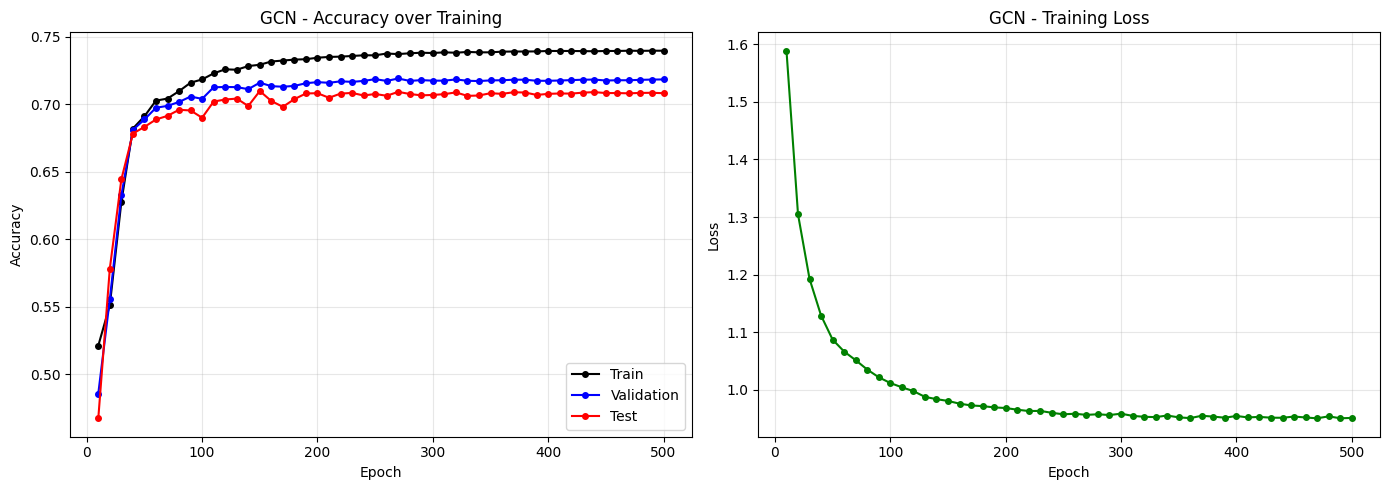

Best Val Acc:  0.7192
Best Test Acc: 0.7093


In [14]:
import matplotlib.pyplot as plt

epochs_logged = list(range(10, 501, 10))

train_accs = [
    0.5211, 0.5512, 0.6277, 0.6821, 0.6912, 0.7028, 0.7043, 0.7098, 0.7161, 0.7185,
    0.7230, 0.7260, 0.7257, 0.7284, 0.7294, 0.7318, 0.7325, 0.7332, 0.7335, 0.7346,
    0.7352, 0.7354, 0.7359, 0.7364, 0.7364, 0.7377, 0.7373, 0.7379, 0.7383, 0.7381,
    0.7386, 0.7383, 0.7389, 0.7386, 0.7386, 0.7391, 0.7392, 0.7392, 0.7393, 0.7396,
    0.7396, 0.7396, 0.7395, 0.7394, 0.7396, 0.7396, 0.7398, 0.7397, 0.7398, 0.7398
]

val_accs = [
    0.4856, 0.5555, 0.6325, 0.6811, 0.6888, 0.6975, 0.6989, 0.7018, 0.7058, 0.7041,
    0.7127, 0.7129, 0.7128, 0.7113, 0.7161, 0.7135, 0.7131, 0.7137, 0.7157, 0.7165,
    0.7160, 0.7171, 0.7167, 0.7174, 0.7187, 0.7174, 0.7192, 0.7174, 0.7180, 0.7176,
    0.7176, 0.7185, 0.7175, 0.7173, 0.7178, 0.7179, 0.7183, 0.7183, 0.7175, 0.7175,
    0.7177, 0.7180, 0.7183, 0.7184, 0.7177, 0.7179, 0.7179, 0.7182, 0.7184, 0.7185
]

test_accs = [
    0.4672, 0.5783, 0.6444, 0.6784, 0.6833, 0.6888, 0.6915, 0.6960, 0.6955, 0.6901,
    0.7021, 0.7036, 0.7043, 0.6988, 0.7099, 0.7025, 0.6982, 0.7039, 0.7081, 0.7083,
    0.7049, 0.7080, 0.7085, 0.7066, 0.7077, 0.7064, 0.7093, 0.7077, 0.7067, 0.7070,
    0.7076, 0.7089, 0.7063, 0.7066, 0.7083, 0.7078, 0.7090, 0.7088, 0.7070, 0.7078,
    0.7081, 0.7080, 0.7087, 0.7091, 0.7084, 0.7084, 0.7082, 0.7085, 0.7086, 0.7083
]

losses = [
    1.5887, 1.3047, 1.1927, 1.1290, 1.0873, 1.0666, 1.0516, 1.0354, 1.0220, 1.0120,
    1.0046, 0.9980, 0.9880, 0.9840, 0.9809, 0.9762, 0.9731, 0.9719, 0.9697, 0.9686,
    0.9657, 0.9634, 0.9636, 0.9603, 0.9577, 0.9587, 0.9567, 0.9578, 0.9564, 0.9588,
    0.9550, 0.9534, 0.9528, 0.9556, 0.9524, 0.9511, 0.9552, 0.9537, 0.9518, 0.9548,
    0.9523, 0.9532, 0.9518, 0.9517, 0.9538, 0.9522, 0.9507, 0.9542, 0.9508, 0.9514
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_logged, train_accs, 'k-o', label='Train', markersize=4)
ax1.plot(epochs_logged, val_accs, 'b-o', label='Validation', markersize=4)
ax1.plot(epochs_logged, test_accs, 'r-o', label='Test', markersize=4)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('GCN - Accuracy over Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, losses, 'g-o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('GCN - Training Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

print("Best Val Acc: ", max(val_accs))
print("Best Test Acc:", test_accs[val_accs.index(max(val_accs))])

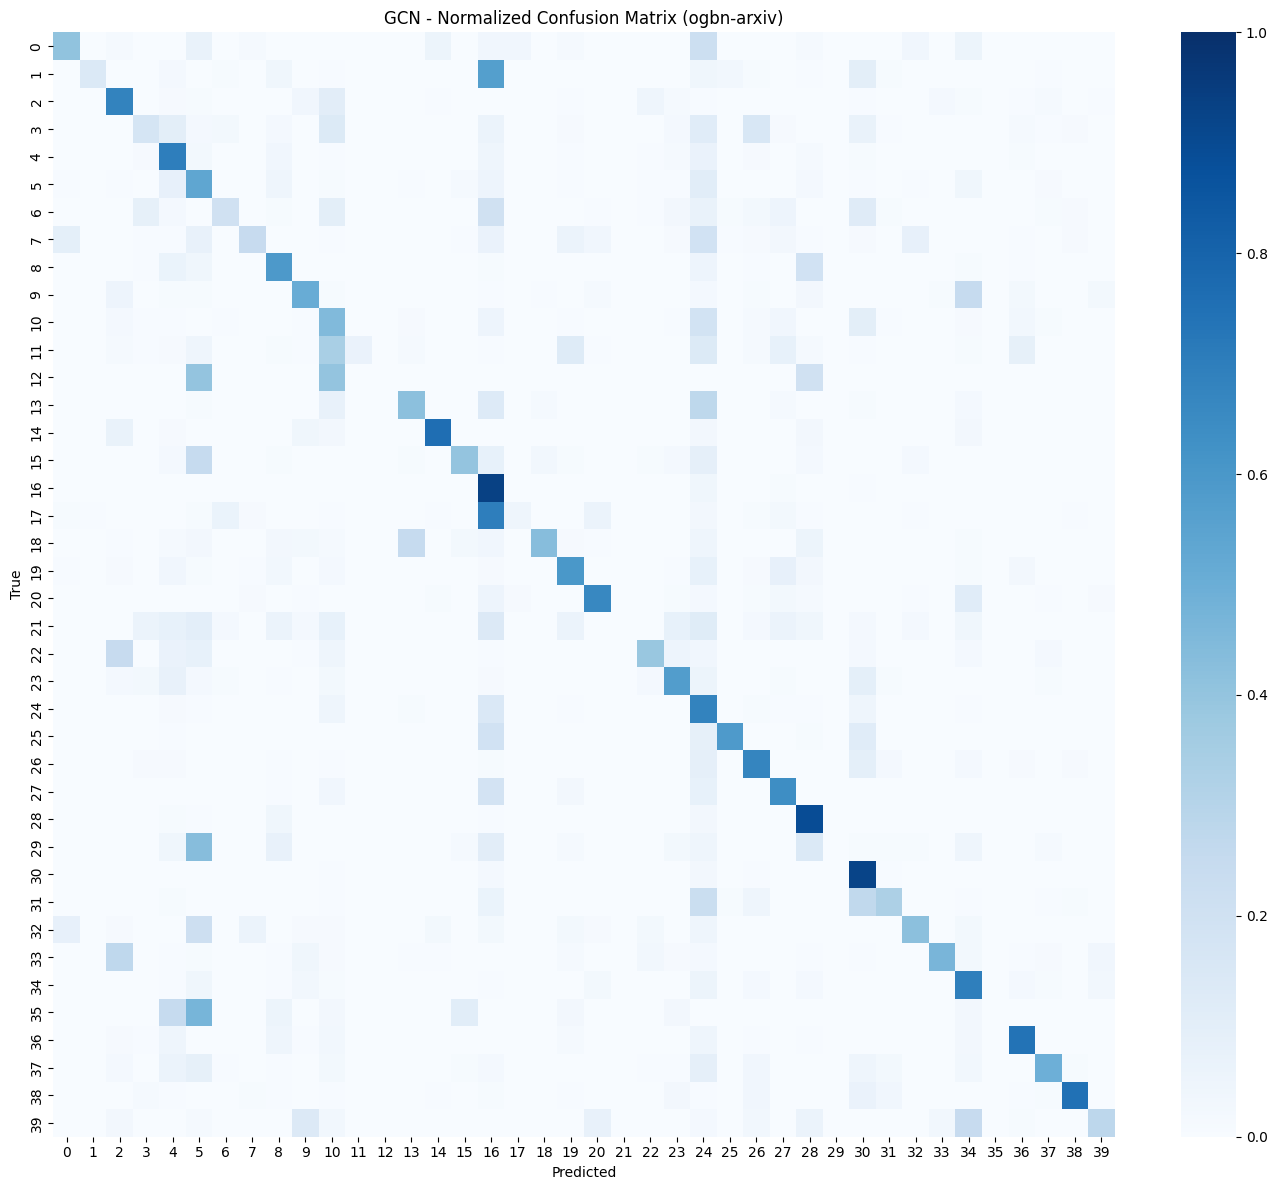

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import os

if os.path.exists('/kaggle/working/best_gcn.pt'):
    model.load_state_dict(torch.load('/kaggle/working/best_gcn.pt', map_location=device))
elif os.path.exists('best_gcn.pt'):
    model.load_state_dict(torch.load('best_gcn.pt', map_location=device))

@torch.no_grad()
def get_test_predictions(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=-1)

    test_preds = pred[test_idx].detach().cpu()
    test_labels = data.y[test_idx].squeeze().detach().cpu()
    return test_labels, test_preds

test_labels, test_preds = get_test_predictions(model)

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy(), labels=list(range(dataset.num_classes)))
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)  # protects against empty classes

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_normalized, cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('GCN - Normalized Confusion Matrix (ogbn-arxiv)')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()


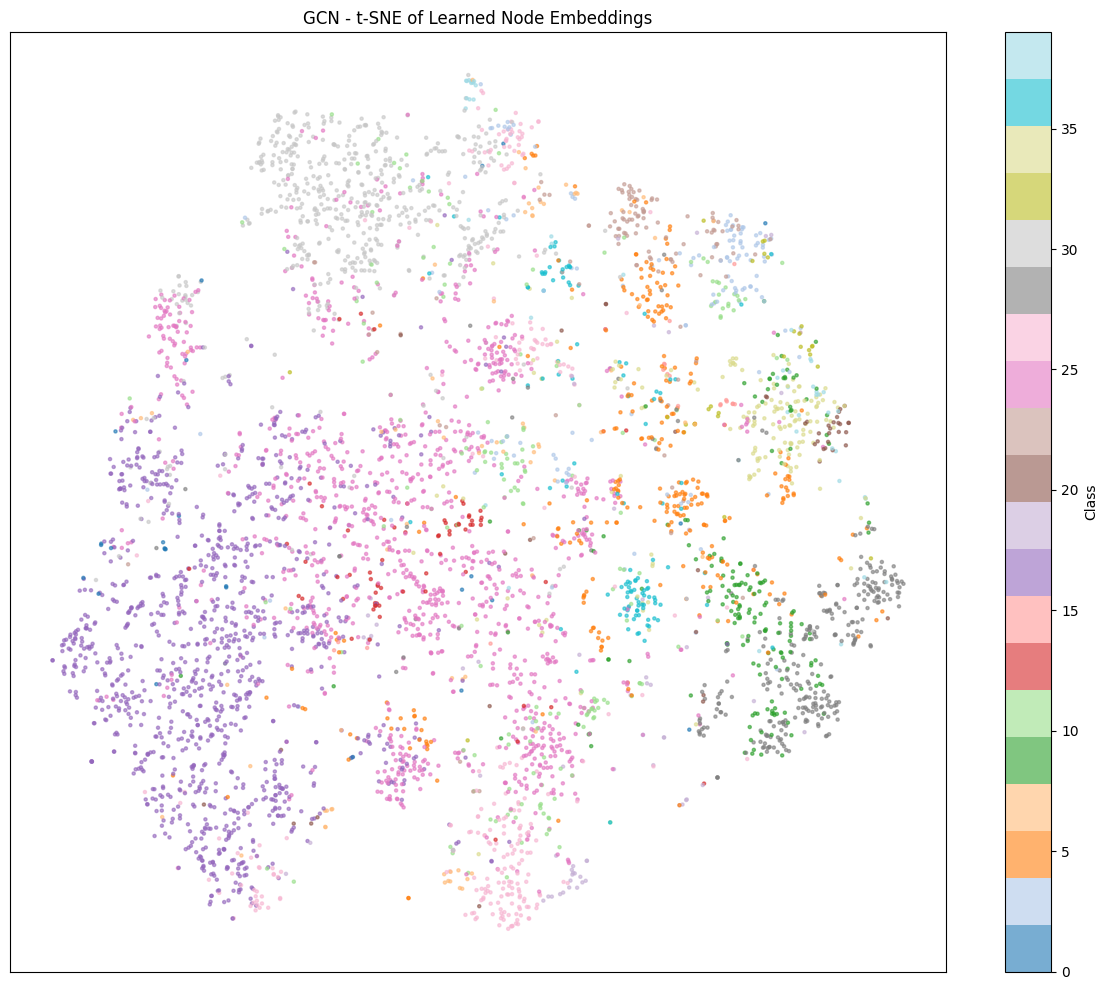

In [16]:
from sklearn.manifold import TSNE
import os

if os.path.exists('/kaggle/working/best_gcn.pt'):
    model.load_state_dict(torch.load('/kaggle/working/best_gcn.pt', map_location=device))
elif os.path.exists('best_gcn.pt'):
    model.load_state_dict(torch.load('best_gcn.pt', map_location=device))

@torch.no_grad()
def get_embeddings(model):
    model.eval()
    x = data.x
    for i, conv in enumerate(model.convs[:-1]):
        x = conv(x, data.edge_index)
        x = model.bns[i](x)
        x = F.relu(x)

    return x.detach().cpu()

all_embeds = get_embeddings(model)
test_embeds = all_embeds[test_idx.cpu()]
test_labels_for_tsne = data.y[test_idx].squeeze().detach().cpu()

n_samples = min(5000, len(test_embeds))
rng = np.random.default_rng(42)
indices = rng.choice(len(test_embeds), n_samples, replace=False)

embeds_sub = test_embeds[indices].numpy()
labels_sub = test_labels_for_tsne[indices].numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
embeds_2d = tsne.fit_transform(embeds_sub)

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(
    embeds_2d[:, 0], embeds_2d[:, 1],
    c=labels_sub,
    cmap='tab20',
    s=5,
    alpha=0.6
)
ax.set_title('GCN - t-SNE of Learned Node Embeddings')
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150)
plt.show()
